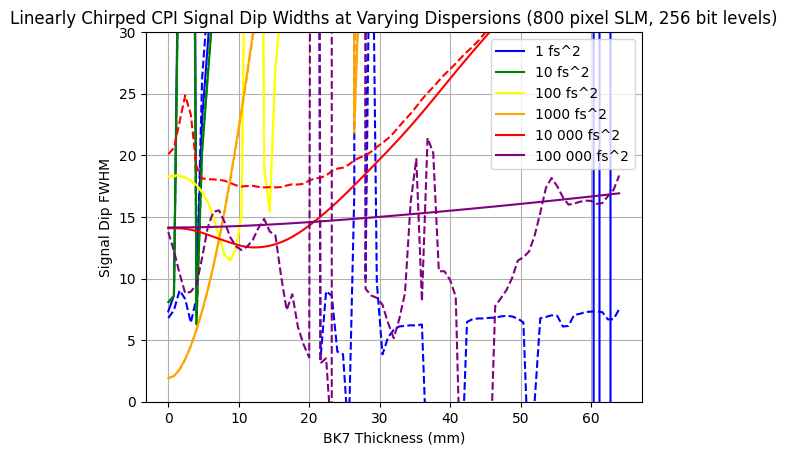

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import matplotlib.ticker as ticker
import os
import math

#for each of linear, erf, super erf, want:
#one array for each of ideal and realistic at each c (so 12 total, 1 for each SLM type)

folder_name = "test_g"
##these are for generating the dip plots further down
Ls = [0, 10000, 50000, 100000, 150000, 200000]
titles = [f'L = {Ls[0]}', f'L = {Ls[1]}', f'L = {Ls[2]}', f'L = {Ls[3]}', f'L = {Ls[4]}', f'L = {Ls[5]}']

realistic_1 = []
realistic_10 = []
realistic_100 = []
realistic_1000 = []
realistic_10k = []
realistic_100k = []

ideal_1 = []
ideal_10 = []
ideal_100 = []
ideal_1000 = []
ideal_10k = []
ideal_100k = []

os.makedirs(f"results/{folder_name}/plots", exist_ok=True)

f = open(f"./results/{folder_name}/plotting_params.txt", "r")
params = f.readlines()
f.close()

dispersion_type = params[0].rstrip()
tau_range = int(params[1])
max_L = int(params[2])
L_stepsize = int(params[3])
bit_levels = int(params[4])
num_pixels = int(params[5])
max_lin_chirp = float(params[6])
max_erf_chirp = float(params[7])
max_superf_chirp = float(params[8])

lin_chirps = [round(num) for num in [max_lin_chirp/10, max_lin_chirp/2, max_lin_chirp, 2*max_lin_chirp, 10*max_lin_chirp]]
erf_chirps = [round(num) for num in [max_erf_chirp/10, max_erf_chirp/2, max_erf_chirp, 2*max_erf_chirp, 10*max_erf_chirp]]
superf_chirps = [round(num) for num in [max_superf_chirp/10, max_superf_chirp/2, max_superf_chirp, 2*max_superf_chirp, 10*max_superf_chirp]]


Lvals = np.arange(0, max_L, L_stepsize)
taus = np.arange(-tau_range, tau_range + 0.5, 0.5)

# --- Initial guesses ---
init_guess = [0, 0.0025, 0.9, 10]

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*np.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

def residuals(params, t, y):
    T0, a1, a2, sigma = params
    model = (a1 - a2 * np.exp(-4 * np.log(2) * (t - T0)**2 / sigma**2))
    return model - y

##not sure if i should normalize, then curve fit or the other way around

for L in Lvals:
    init_guess = [0, 0.00015*L, 0.9, 10]

    r_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1/realistic/L{L}.txt")
    r_10 = np.loadtxt(f"./results/{folder_name}/linear/chirp_10/realistic/L{L}.txt")
    r_100 = np.loadtxt(f"./results/{folder_name}/linear/chirp_100/realistic/L{L}.txt")
    r_1000 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1000/realistic/L{L}.txt")
    r_10k = np.loadtxt(f"./results/{folder_name}/linear/chirp_10000/realistic/L{L}.txt")
    r_100k = np.loadtxt(f"./results/{folder_name}/linear/chirp_100000/realistic/L{L}.txt")

    i_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1/ideal/L{L}.txt")
    i_10 = np.loadtxt(f"./results/{folder_name}/linear/chirp_10/ideal/L{L}.txt")
    i_100 = np.loadtxt(f"./results/{folder_name}/linear/chirp_100/ideal/L{L}.txt")
    i_1000 = np.loadtxt(f"./results/{folder_name}/linear/chirp_1000/ideal/L{L}.txt")
    i_10k = np.loadtxt(f"./results/{folder_name}/linear/chirp_10000/ideal/L{L}.txt")
    i_100k = np.loadtxt(f"./results/{folder_name}/linear/chirp_100000/ideal/L{L}.txt")
    

    # --- Fit the data ---
    #pretty sure maggies code uses the LevenbergMarquardt method, at least for the 0 dispersion dip
    realistic_1.append(least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10.append(least_squares(residuals, init_guess, args=(taus, r_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100.append(least_squares(residuals, init_guess, args=(taus, r_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_1000.append(least_squares(residuals, init_guess, args=(taus, r_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10k.append(least_squares(residuals, init_guess, args=(taus, r_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100k.append(least_squares(residuals, init_guess, args=(taus, r_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])

    ideal_1.append(least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10.append(least_squares(residuals, init_guess, args=(taus, i_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100.append(least_squares(residuals, init_guess, args=(taus, i_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_1000.append(least_squares(residuals, init_guess, args=(taus, i_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10k.append(least_squares(residuals, init_guess, args=(taus, i_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100k.append(least_squares(residuals, init_guess, args=(taus, i_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])


plt.plot(Lvals, ideal_1, label = "1 fs^2", color = 'blue')
plt.plot(Lvals, realistic_1, color = 'blue', linestyle = 'dashed')

plt.plot(Lvals, ideal_10, label = "10 fs^2", color = 'green')
plt.plot(Lvals, realistic_10, color = 'green', linestyle = 'dashed')

plt.plot(Lvals, ideal_100, label = "100 fs^2", color = 'yellow')
plt.plot(Lvals, realistic_100, color = 'yellow', linestyle = 'dashed')

plt.plot(Lvals, ideal_1000, label = "1000 fs^2", color = 'orange')
plt.plot(Lvals, realistic_1000, color = 'orange', linestyle = 'dashed')

plt.plot(Lvals, ideal_10k, label = "10 000 fs^2", color = 'red')
plt.plot(Lvals, realistic_10k, color = 'red', linestyle = 'dashed')

plt.plot(Lvals, ideal_100k, label = "100 000 fs^2", color = 'purple')
plt.plot(Lvals, realistic_100k, color = 'purple', linestyle = 'dashed')
plt.xlabel(f"{dispersion_type} Thickness (mm)")
plt.ylabel("Signal Dip FWHM")
plt.legend()
plt.grid()
plt.title(f'Linearly Chirped CPI Signal Dip Widths at Varying Dispersions ({num_pixels} pixel SLM, {bit_levels} bit levels)')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
plt.ylim(0, 30);
plt.savefig(f"results/{folder_name}/plots/linear_dip_widths.png")

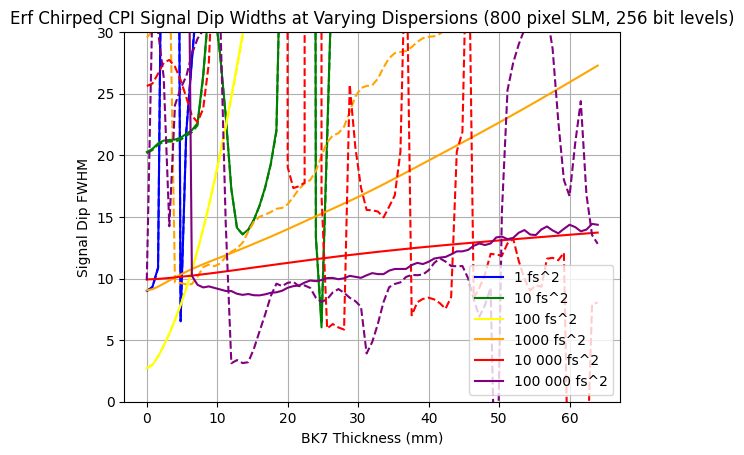

In [25]:
#for each of linear, erf, super erf, want:
#one array for each of ideal and realistic at each c (so 12 total, 1 for each SLM type)

realistic_1 = []
realistic_10 = []
realistic_100 = []
realistic_1000 = []
realistic_10k = []
realistic_100k = []

ideal_1 = []
ideal_10 = []
ideal_100 = []
ideal_1000 = []
ideal_10k = []
ideal_100k = []

##not sure if i should normalize, then curve fit or the other way around

for L in Lvals:
    init_guess = [0, 0.00015*L, 0.9, 10]

    r_1 = np.loadtxt(f"./results/{folder_name}/erf/chirp_1/realistic/L{L}.txt")
    r_10 = np.loadtxt(f"./results/{folder_name}/erf/chirp_10/realistic/L{L}.txt")
    r_100 = np.loadtxt(f"./results/{folder_name}/erf/chirp_100/realistic/L{L}.txt")
    r_1000 = np.loadtxt(f"./results/{folder_name}/erf/chirp_1000/realistic/L{L}.txt")
    r_10k = np.loadtxt(f"./results/{folder_name}/erf/chirp_10000/realistic/L{L}.txt")
    r_100k = np.loadtxt(f"./results/{folder_name}/erf/chirp_100000/realistic/L{L}.txt")

    i_1 = np.loadtxt(f"./results/{folder_name}/erf/chirp_1/ideal/L{L}.txt")
    i_10 = np.loadtxt(f"./results/{folder_name}/erf/chirp_10/ideal/L{L}.txt")
    i_100 = np.loadtxt(f"./results/{folder_name}/erf/chirp_100/ideal/L{L}.txt")
    i_1000 = np.loadtxt(f"./results/{folder_name}/erf/chirp_1000/ideal/L{L}.txt")
    i_10k = np.loadtxt(f"./results/{folder_name}/erf/chirp_10000/ideal/L{L}.txt")
    i_100k = np.loadtxt(f"./results/{folder_name}/erf/chirp_100000/ideal/L{L}.txt")
    

    # --- Fit the data ---
    #pretty sure maggies code uses the LevenbergMarquardt method, at least for the 0 dispersion dip
    realistic_1.append(least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10.append(least_squares(residuals, init_guess, args=(taus, r_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100.append(least_squares(residuals, init_guess, args=(taus, r_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_1000.append(least_squares(residuals, init_guess, args=(taus, r_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_10k.append(least_squares(residuals, init_guess, args=(taus, r_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    realistic_100k.append(least_squares(residuals, init_guess, args=(taus, r_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])

    ideal_1.append(least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10.append(least_squares(residuals, init_guess, args=(taus, i_10), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100.append(least_squares(residuals, init_guess, args=(taus, i_100), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_1000.append(least_squares(residuals, init_guess, args=(taus, i_1000), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_10k.append(least_squares(residuals, init_guess, args=(taus, i_10k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])
    ideal_100k.append(least_squares(residuals, init_guess, args=(taus, i_100k), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15).x[3])


plt.plot(Lvals, ideal_1, label = "1 fs^2", color = 'blue')
plt.plot(Lvals, realistic_1, color = 'blue', linestyle = 'dashed')

plt.plot(Lvals, ideal_10, label = "10 fs^2", color = 'green')
plt.plot(Lvals, realistic_10, color = 'green', linestyle = 'dashed')

plt.plot(Lvals, ideal_100, label = "100 fs^2", color = 'yellow')
plt.plot(Lvals, realistic_100, color = 'yellow', linestyle = 'dashed')

plt.plot(Lvals, ideal_1000, label = "1000 fs^2", color = 'orange')
plt.plot(Lvals, realistic_1000, color = 'orange', linestyle = 'dashed')

plt.plot(Lvals, ideal_10k, label = "10 000 fs^2", color = 'red')
plt.plot(Lvals, realistic_10k, color = 'red', linestyle = 'dashed')

plt.plot(Lvals, ideal_100k, label = "100 000 fs^2", color = 'purple')
plt.plot(Lvals, realistic_100k, color = 'purple', linestyle = 'dashed')
plt.xlabel(f"{dispersion_type} Thickness (mm)")
plt.ylabel("Signal Dip FWHM")
plt.legend()
plt.grid()
plt.title(f'Erf Chirped CPI Signal Dip Widths at Varying Dispersions ({num_pixels} pixel SLM, {bit_levels} bit levels)')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
plt.ylim(0, 30);
plt.savefig(f"results/{folder_name}/plots/erf_dip_widths.png")

Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Ideal: [1.24939008e-11 3.65936806e-02 3.55051953e-02 1.40851082e+01]
Final Chi-Squared Value for L = 0 - Ideal: 1.0571318733947073e-06
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Ideal: [ 0.61437338  0.02290297  0.0216284  20.87181828]
Final Chi-Squared Value for L = 32000 - Ideal: 0.0009057535759129453
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Ideal: [5.29346053e-01 1.47625236e-02 1.45082122e-02 4.34728087e+01]
Final Chi-Squared Value for L = 64000 - Ideal: 0.00040814580850602765
Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Realistic: [4.25293565e-11 2.73673430e-02 2.96344850e-02 2.00848089e+01]
Final Chi-Squared Value for L = 0 - Realistic: 0.007072433626077042
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Realistic: [5.50371711e-01 1.92639408e-02 1.80961600e-02 2.18324609e+01]
Final Chi-Squared Value for L = 32000 - Realistic: 0.0007214984153795342
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Realistic: [3.9749556

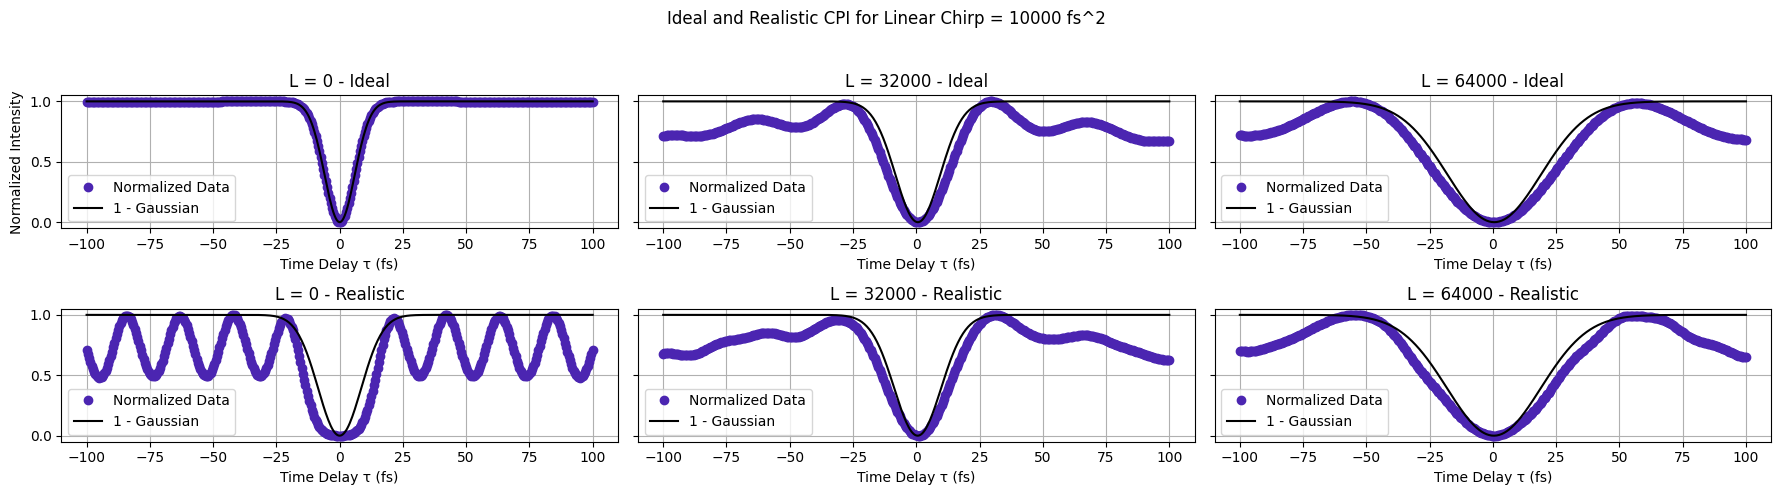

In [15]:
signals = []
curve_fits = []
params = []

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*math.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

chirp = 10000

fit_names= []
Ls = [0, 32000, 64000]
ideal_names = ["L = 0 - Ideal", "L = 32000 - Ideal", "L = 64000 - Ideal"]
real_names = ["L = 0 - Realistic", "L = 32000 - Realistic", "L = 64000 - Realistic"]
total_names = []

for L, name in zip(Ls, ideal_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_{chirp}/ideal/L{L}.txt")

    signal_vs_tau_norm = (i_1 - np.min(i_1))/(np.max(i_1) - np.min(i_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for L, name in zip(Ls, real_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_{chirp}/realistic/L{L}.txt")

    signal_vs_tau_norm = (r_1 - np.min(r_1))/(np.max(r_1) - np.min(r_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit in zip(axes, signals, curve_fits, total_names, fit_names):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.tight_layout()
plt.suptitle(f"Ideal and Realistic CPI for Linear Chirp = {chirp} fs^2")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.show();

Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Ideal: [2.11335341e-12 3.70582901e-03 3.55805541e-03 1.41404315e+01]
Final Chi-Squared Value for L = 0 - Ideal: 9.035166138767109e-12
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Ideal: [1.56066107e+00 3.71196625e-03 3.40774983e-03 1.51017062e+01]
Final Chi-Squared Value for L = 32000 - Ideal: 2.903970999817143e-06
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Ideal: [2.41331782e+00 3.71981468e-03 3.12869948e-03 1.69161962e+01]
Final Chi-Squared Value for L = 64000 - Ideal: 5.041756311400564e-06
Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Realistic: [-1.65179722e-14  1.14366135e-03  4.35542459e-04  1.37694789e+01]
Final Chi-Squared Value for L = 0 - Realistic: 3.8240731650296995e-05
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Realistic: [3.69300977e+00 1.89337687e-03 7.64948338e-04 5.15509925e+00]
Final Chi-Squared Value for L = 32000 - Realistic: 0.00011291408140546742
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Real

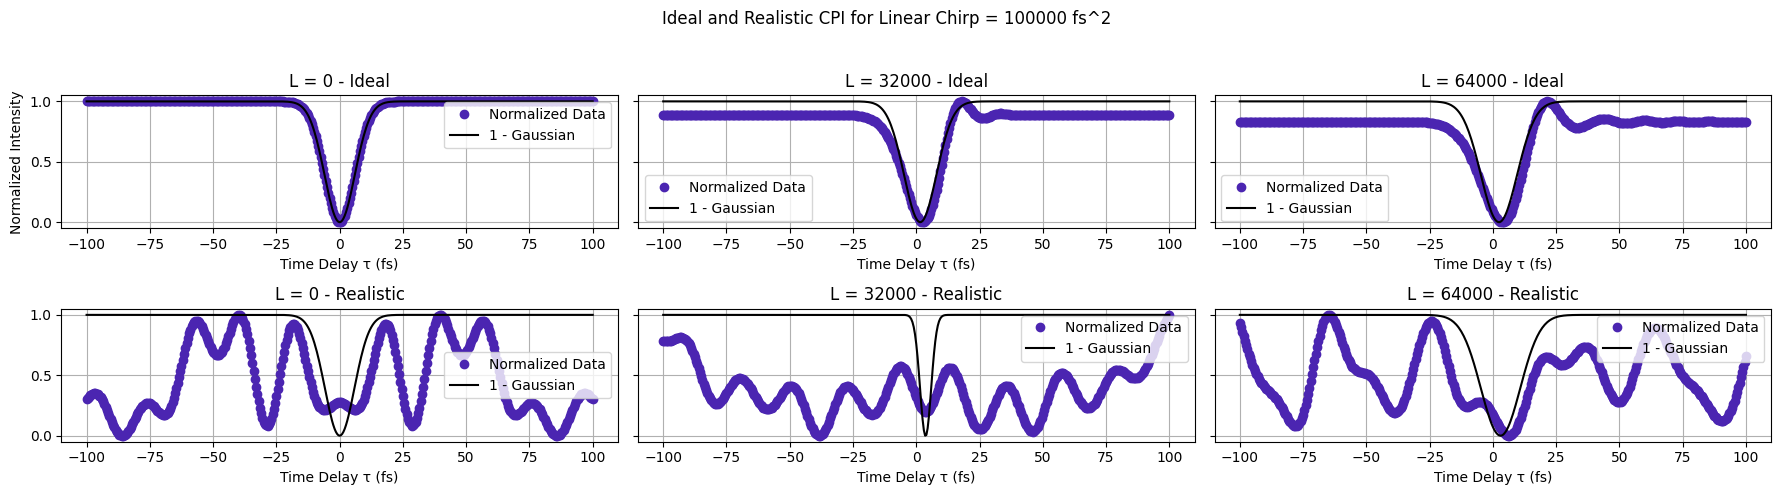

In [16]:
signals = []
curve_fits = []
params = []

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*math.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

chirp = 100000

fit_names= []
Ls = [0, 32000, 64000]
ideal_names = ["L = 0 - Ideal", "L = 32000 - Ideal", "L = 64000 - Ideal"]
real_names = ["L = 0 - Realistic", "L = 32000 - Realistic", "L = 64000 - Realistic"]
total_names = []

for L, name in zip(Ls, ideal_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_{chirp}/ideal/L{L}.txt")

    signal_vs_tau_norm = (i_1 - np.min(i_1))/(np.max(i_1) - np.min(i_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for L, name in zip(Ls, real_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/linear/chirp_{chirp}/realistic/L{L}.txt")

    signal_vs_tau_norm = (r_1 - np.min(r_1))/(np.max(r_1) - np.min(r_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit in zip(axes, signals, curve_fits, total_names, fit_names):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.tight_layout()
plt.suptitle(f"Ideal and Realistic CPI for Linear Chirp = {chirp} fs^2")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.show();

Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Ideal: [-2.89409138e-11  2.30696190e-02  2.30535077e-02  9.04338143e+00]
Final Chi-Squared Value for L = 0 - Ideal: 0.0002854612507210351
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Ideal: [9.44777962e-01 1.64810889e-02 1.58757404e-02 1.71845498e+01]
Final Chi-Squared Value for L = 32000 - Ideal: 0.0001620262274566862
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Ideal: [8.21093830e-01 1.18590363e-02 1.07668467e-02 2.72854777e+01]
Final Chi-Squared Value for L = 64000 - Ideal: 0.00010334333654458547
Fit Parameters (t0, a1, a2, fwhm) for L = 0 - Realistic: [4.22140677e-11 1.49141462e-02 1.29607297e-02 2.95739448e+01]
Final Chi-Squared Value for L = 0 - Realistic: 0.005293570778136576
Fit Parameters (t0, a1, a2, fwhm) for L = 32000 - Realistic: [5.76579680e-01 1.02206587e-02 9.02679085e-03 2.56885865e+01]
Final Chi-Squared Value for L = 32000 - Realistic: 2.536205799073103e-05
Fit Parameters (t0, a1, a2, fwhm) for L = 64000 - Realis

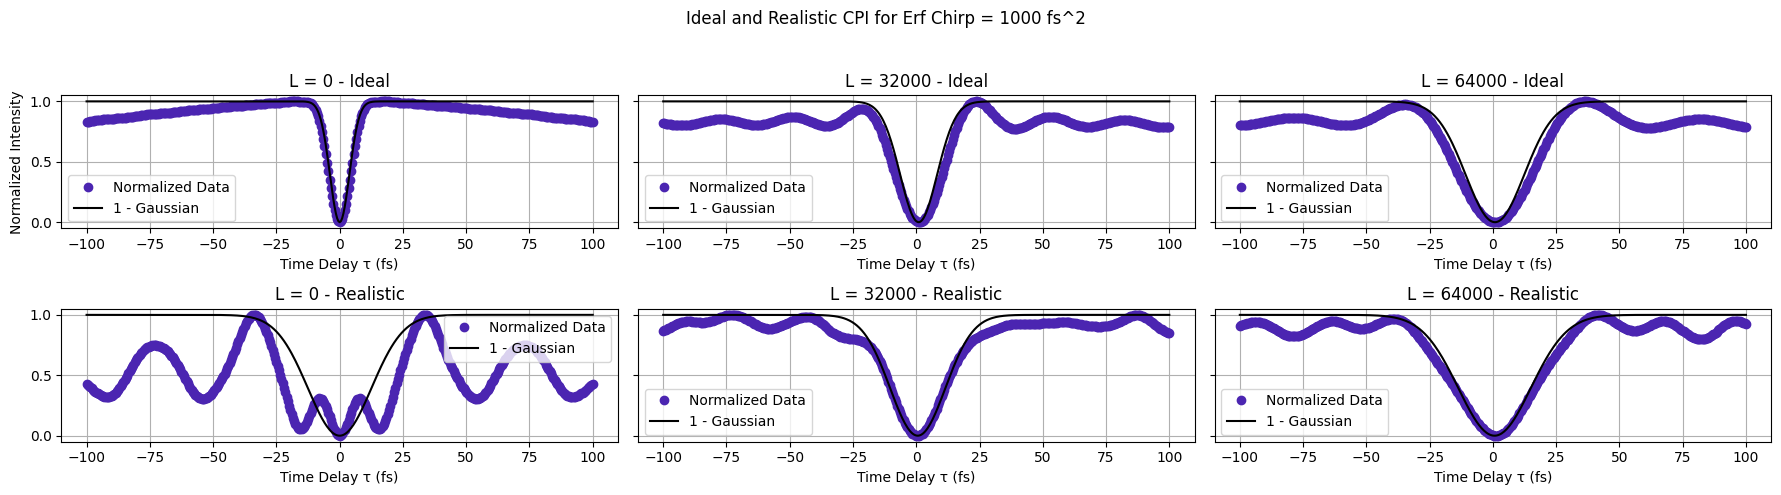

In [ ]:
signals = []
curve_fits = []
params = []

def one_minus_gaussian(t, t_0, a1, a2, fwhm):
    return a1 - a2*np.exp(-4*math.log(2)*((t - t_0)**2)/fwhm**2)

def chisq(params, t, y):
    t0, a1, a2, fwhm = params
    model = one_minus_gaussian(t, t0, a1, a2, fwhm)
    return np.sum((y - model)**2)

chirp = 1000

fit_names= []
Ls = [0, 32000, 64000]
ideal_names = [f"L = {Ls[0]} - Ideal", f"L = {Ls[1]} - Ideal", f"L = {Ls[2]} - Ideal"]
real_names = [f"L = {Ls[0]} - Realistic", f"L = {Ls[1]} - Realistic", f"L = {Ls[2]} - Realistic"]
total_names = []

for L, name in zip(Ls, ideal_names):

    i_1 = np.loadtxt(f"./results/{folder_name}/erf/chirp_{chirp}/ideal/L{L}.txt")

    signal_vs_tau_norm = (i_1 - np.min(i_1))/(np.max(i_1) - np.min(i_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, i_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)

for L, name in zip(Ls, real_names):

    r_1 = np.loadtxt(f"./results/{folder_name}/erf/chirp_{chirp}/realistic/L{L}.txt")

    signal_vs_tau_norm = (r_1 - np.min(r_1))/(np.max(r_1) - np.min(r_1))
    signals.append(signal_vs_tau_norm)

    # --- Initial guesses ---
    init_guess = [0.0, 0.0025, 0.9, 10.0]  # Corrected to 3 parameters

    # --- Fit the data ---
    result = least_squares(residuals, init_guess, args=(taus, r_1), method='lm', 
                               ftol=1e-15, xtol=1e-15, gtol=1e-15)

    # Extract the parameters
    params.append(result.x)

    # Calculate the final chi-squared values
    final_chisq = result.cost

    # Print the fit parameters and chi-squared values
    print(f"Fit Parameters (t0, a1, a2, fwhm) for {name}: {result.x}")
    print(f"Final Chi-Squared Value for {name}: {final_chisq}")

    # Evaluate the fits
    curve = one_minus_gaussian(taus, *result.x)
    curve_norm =  (curve - np.min(curve))/(np.max(curve) - np.min(curve))
    curve_fits.append(curve_norm)
    fit_names.append("1 - Gaussian")
    total_names.append(name)


# --- Create subplots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 5), sharey=True)

axes = axes.flatten()

for ax, signal, curve, name, fit in zip(axes, signals, curve_fits, total_names, fit_names):
    ax.plot(taus, signal, 'o', label='Normalized Data', color='#4B25B1')
    ax.plot(taus, curve, '-', label=fit, color='black')
    ax.set_xlabel('Time Delay τ (fs)')
    ax.set_title(name)
    ax.legend()
    ax.grid(True)

    # --- Optional: print fitted parameters ---
    #print(f"Fitted parameters for {name}: a = {param[0]:.4f}, t0 = {param[1]:.4f} fs, FWHM = {param[2]:.4f} fs")
    
axes[0].set_ylabel('Normalized Intensity')
plt.tight_layout()
plt.suptitle(f"Ideal and Realistic CPI for Erf Chirp = {chirp} fs^2")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # second
plt.show();